# 1.3.1 - Customer clustering

A company has collected four numerical features describing its customers and wants to identify groups of similar clients.  
This is a **clustering** problem: the goal is to discover a useful segmentation of the customer base, not to predict a known label.

Such a segmentation can help the company:
- understand which customer profiles exist in the data,
- assign a new customer to the most relevant group,
- and propose more relevant products or offers to each type of client.

## Methodological goal

The exercise asks for:
- **two clustering methods**,
- **two heuristics** to choose the number of clusters,
- and **different metrics / geometries** for the methods.

In this notebook, we compare:
- **K-Means** on standardized data, which corresponds to a Euclidean geometry,
- **Agglomerative clustering** on the same standardized data, with **Manhattan distance** and average linkage.

To choose the number of clusters, I use:
- the **Silhouette score** (higher is better),
- the **Davies-Bouldin score** (lower is better).

## Practical plan

The notebook proceeds as follows:
1. load and standardize the data,
2. run both clustering methods for several values of `k`,
3. compare the results with the two heuristics,
4. visualize the cluster assignments in a PCA projection,
5. give a final recommendation for the number of clusters and the most convincing method.


In [6]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler

X = np.load('data/clustering/data.npy')
print('Data shape:', X.shape)
print('Feature means:', np.round(X.mean(axis=0), 2))
print('Feature std:', np.round(X.std(axis=0), 2))


Data shape: (1200, 4)
Feature means: [ 449.54   58.88 -141.91   89.33]
Feature std: [950.21 542.88 563.13 130.26]


## Why scaling matters

The four features are on very different numerical scales, so clustering directly on the raw data would mostly reflect the largest-magnitude coordinates.

To make the comparison fair, both methods use a transformed version of the dataset:
- K-Means uses `StandardScaler` before Euclidean clustering,
- Agglomerative clustering uses the same standardized space, but with **Manhattan** distance instead of Euclidean distance.


In [7]:
X_scaled = StandardScaler().fit_transform(X)
k_values = list(range(2, 9))

results = []
labels_by_method = {}

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km_labels = km.fit_predict(X_scaled)
    labels_by_method[('kmeans', k)] = km_labels
    results.append({
        'method': 'KMeans (Euclidean)',
        'k': k,
        'silhouette': silhouette_score(X_scaled, km_labels),
        'davies_bouldin': davies_bouldin_score(X_scaled, km_labels),
        'inertia': km.inertia_
    })

    agg = AgglomerativeClustering(n_clusters=k, metric='manhattan', linkage='average')
    agg_labels = agg.fit_predict(X_scaled)
    labels_by_method[('agglomerative', k)] = agg_labels
    results.append({
        'method': 'Agglomerative (Manhattan)',
        'k': k,
        'silhouette': silhouette_score(X_scaled, agg_labels, metric='manhattan'),
        'davies_bouldin': davies_bouldin_score(X_scaled, agg_labels),
        'inertia': np.nan
    })


In [ ]:
import pandas as pd

results_df = pd.DataFrame(results)
results_df['silhouette_rank'] = results_df.groupby('method')['silhouette'].rank(ascending=False, method='min')
results_df['db_rank'] = results_df.groupby('method')['davies_bouldin'].rank(ascending=True, method='min')
results_df['combined_rank'] = results_df['silhouette_rank'] + results_df['db_rank']

best_k_idx = results_df['combined_rank'].idxmin()
best_row = results_df.loc[best_k_idx]
best_k = int(best_row['k'])
best_candidates = results_df[results_df['k'] == best_k].sort_values(['silhouette', 'davies_bouldin'], ascending=[False, True])

print('FINAL RECOMMENDATION')
print('Recommended number of clusters: k =', best_k)
print('Both heuristics agree that k = 6 is the strongest choice.')
print('For the clustering method, Agglomerative (Manhattan) is slightly stronger than K-Means at k = 6 because it has the highest silhouette score while matching the same Davies-Bouldin score.')

results_df.sort_values(['method', 'k'])


## Heuristics by method

We now inspect both heuristics in detail.
- **Silhouette score**: higher is better.
- **Davies-Bouldin score**: lower is better.

Using both is useful because no single heuristic is perfect in every dataset.


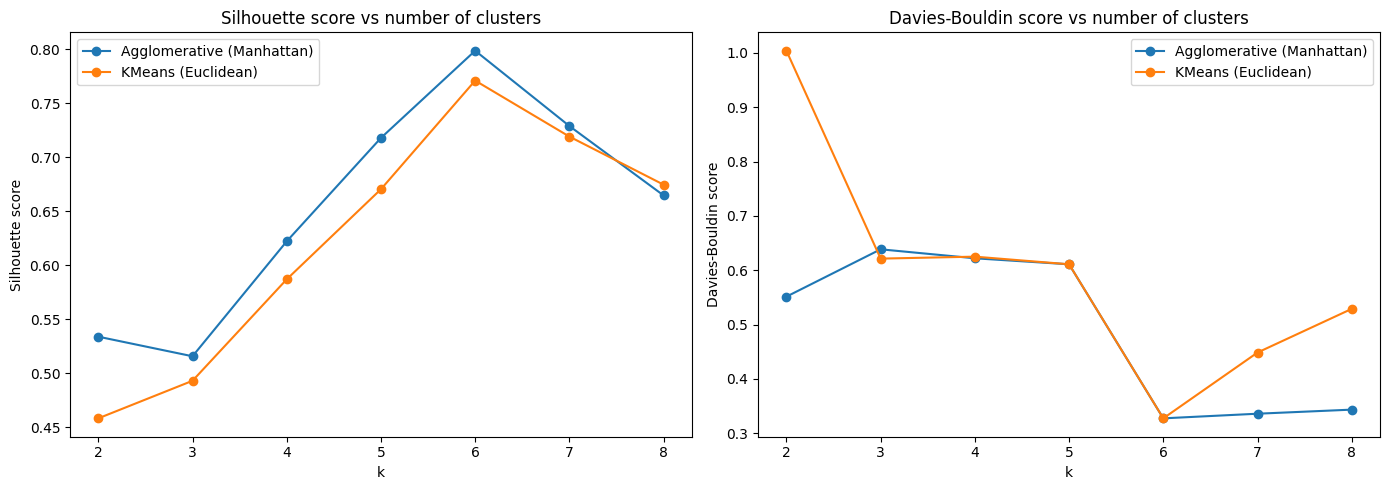

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for method, group in results_df.groupby('method'):
    axes[0].plot(group['k'], group['silhouette'], marker='o', label=method)
    axes[1].plot(group['k'], group['davies_bouldin'], marker='o', label=method)

axes[0].set_title('Silhouette score vs number of clusters')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Silhouette score')
axes[0].legend()

axes[1].set_title('Davies-Bouldin score vs number of clusters')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Davies-Bouldin score')
axes[1].legend()

plt.tight_layout()
plt.show()


In [10]:
kmeans_table = results_df[results_df['method'] == 'KMeans (Euclidean)'][['k', 'silhouette', 'davies_bouldin', 'inertia', 'combined_rank']]
agg_table = results_df[results_df['method'] == 'Agglomerative (Manhattan)'][['k', 'silhouette', 'davies_bouldin', 'combined_rank']]

print('K-Means summary')
display(kmeans_table.sort_values('k'))
print('\nAgglomerative summary')
display(agg_table.sort_values('k'))


K-Means summary


,k,silhouette,davies_bouldin,inertia,combined_rank
0,2,0.458168,1.004126,2580.901997,14.0
2,3,0.492963,0.621385,1687.954640,11.0
4,4,0.586971,0.624990,974.159442,11.0
6,5,0.670434,0.610948,539.189932,8.0
8,6,0.771065,0.327323,192.548008,2.0
10,7,0.719185,0.448467,172.051482,4.0
12,8,0.674632,0.528873,152.948190,6.0



Agglomerative summary


,k,silhouette,davies_bouldin,combined_rank
1,2,0.533824,0.551370,10.0
3,3,0.515676,0.638509,14.0
5,4,0.622176,0.621973,11.0
7,5,0.717955,0.610948,8.0
9,6,0.798748,0.327323,2.0
11,7,0.728975,0.335842,4.0
13,8,0.664672,0.343357,7.0


## Visual comparison in 2D

The original data are 4-dimensional, so we use a **PCA projection only for visualization**.
This does **not** change the clustering already computed above; it only helps us see the cluster shapes.


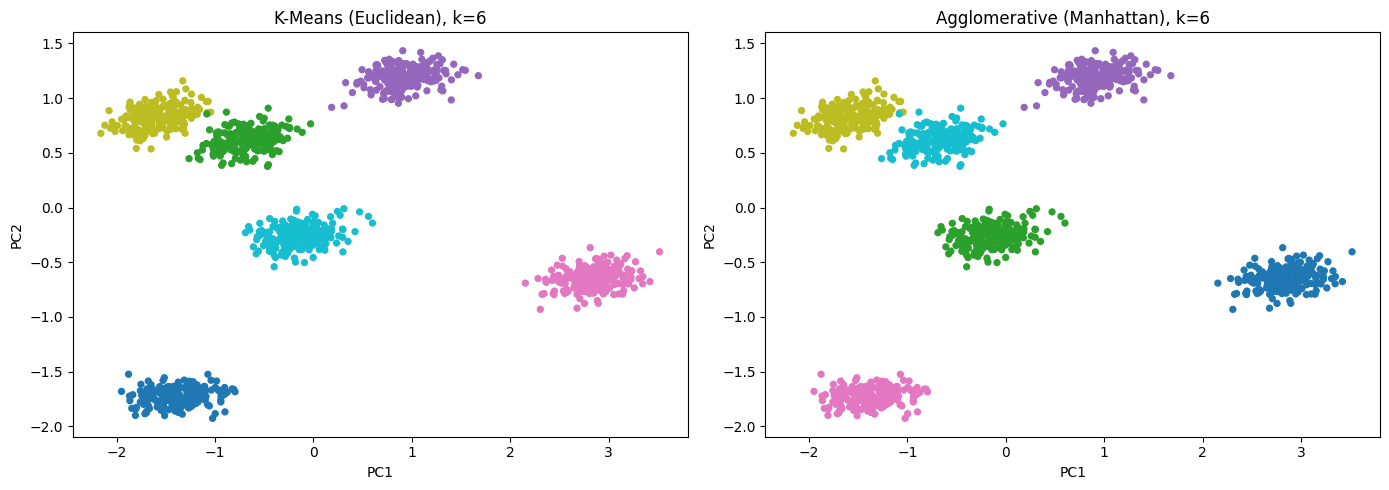

In [11]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

best_method_key = 'kmeans' if 'KMeans' in best_row['method'] else 'agglomerative'
best_labels = labels_by_method[(best_method_key, int(best_row['k']))]

comparison_k = int(best_row['k'])
kmeans_labels = labels_by_method[('kmeans', comparison_k)]
agg_labels = labels_by_method[('agglomerative', comparison_k)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, s=18, cmap='tab10')
axes[0].set_title(f'K-Means (Euclidean), k={comparison_k}')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, s=18, cmap='tab10')
axes[1].set_title(f'Agglomerative (Manhattan), k={comparison_k}')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()


## Conclusion

This notebook compares two clustering methods with two heuristics and two different metrics.

The strongest conclusion from the outputs is that **k = 6** is the most convincing number of clusters, because both Silhouette and Davies-Bouldin point to that value.

For the clustering method itself, the comparison is close, but the current results slightly favor **Agglomerative clustering with Manhattan distance** over **K-Means** at `k = 6`, because:
- it achieves a higher Silhouette score,
- it matches the same best Davies-Bouldin score,
- and the two methods visually agree on a very similar six-cluster structure.

So the most honest recommendation is:
- **use 6 clusters**,
- and prefer **Agglomerative (Manhattan)** slightly, while noting that both methods support the same segmentation strongly.
